In [1]:
%pip install datasets pandas pyarrow


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import re
import os
import pandas as pd
from datasets import load_dataset



c:\Users\Naina Jain\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [27]:
dataset = load_dataset(
    "ai4bharat/IndicCorpV2",
    "indiccorp_v2",
    split="hin_Deva",
    streaming=True
)
print("Dataset stream initialized successfully.")



Dataset stream initialized successfully.


In [5]:
URL_PATTERN = r'https?://[^\s]+|www\.[^\s]+'

EMAIL_PATTERN = r'[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Za-z]{2,}'

DATE_PATTERN = r'\b\d{1,2}[/-]\d{1,2}[/-]\d{2,4}\b'

NUMBER_PATTERN = r'\b\d+\.\d+\b|\b\d+\b'

PUNCT_PATTERN = r'[।!?.,;:"()\[\]{}<>…]'

In [6]:
def sentence_tokenizer(paragraph):

    paragraph = paragraph.strip()

    if paragraph == "":
        return []

    sentences = re.split(r'(?<=[।!?])\s+', paragraph)

    output = []

    for sentence in sentences:

        sentence = sentence.strip()

        if sentence != "":
            output.append(sentence)

    return output


In [41]:
TOKEN_PATTERN = re.compile(
    f"{URL_PATTERN}"
    f"|{EMAIL_PATTERN}"
    f"|{DATE_PATTERN}"
    f"|{NUMBER_PATTERN}"
    r"|[\u0900-\u097F]+"
    r"|[A-Za-z]+"
    f"|{PUNCT_PATTERN}"
)

def word_tokenizer(sentence):

    tokens = TOKEN_PATTERN.findall(sentence)

    return tokens


In [44]:
sample = """
आज मौसम अच्छा है।
मेरा ईमेल abc@gmail.com है।
वेबसाइट https://huggingface.co देखिए।
आज तारीख 15/08/2026 है।
कीमत 25.75 रुपये है!
"""

sentences = sentence_tokenizer(sample)

for sentence in sentences:

    print("Sentence:")
    print(sentence)

    print("Tokens:")
    print(word_tokenizer(sentence))

    print("-"*50)


Sentence:
आज मौसम अच्छा है।
Tokens:
['आज', 'मौसम', 'अच्छा', 'है।']
--------------------------------------------------
Sentence:
मेरा ईमेल abc@gmail.com है।
Tokens:
['मेरा', 'ईमेल', 'abc@gmail.com', 'है।']
--------------------------------------------------
Sentence:
वेबसाइट https://huggingface.co देखिए।
Tokens:
['वेबसाइट', 'https://huggingface.co', 'देखिए।']
--------------------------------------------------
Sentence:
आज तारीख 15/08/2026 है।
Tokens:
['आज', 'तारीख', '15/08/2026', 'है।']
--------------------------------------------------
Sentence:
कीमत 25.75 रुपये है!
Tokens:
['कीमत', '25.75', 'रुपये', 'है', '!']
--------------------------------------------------


In [30]:
os.makedirs("output", exist_ok=True)

all_words = []

sentence_count = 0
character_count = 0

with open("output/tokenized_sentences.txt", "w", encoding="utf-8") as file:

    for i, row in enumerate(dataset):

        if i == 1000000:
            break

        if (i + 1) % 100000 == 0:
            print(f"Processed {i + 1} rows...")

        paragraph = row["text"]

        if paragraph is None:
            continue

        sentences = sentence_tokenizer(paragraph)

        sentence_count += len(sentences)

        for sentence in sentences:

            tokens = word_tokenizer(sentence)

            if len(tokens) == 0:
                continue

            # Write one tokenized sentence per line
            file.write("#".join(tokens))
            file.write("\n")

            # Statistics
            for token in tokens:
                all_words.append(token)
                character_count += len(token)

print("\nFinished Processing!")
print("Total Rows Processed:", min(i + 1, 1000000))
print("Tokenized text file saved successfully.")

Processed 100000 rows...
Processed 200000 rows...
Processed 300000 rows...


Got disconnected from remote data host. Retrying in 5sec [1/20]


Processed 400000 rows...
Processed 500000 rows...
Processed 600000 rows...
Processed 700000 rows...
Processed 800000 rows...
Processed 900000 rows...
Processed 1000000 rows...

Finished Processing!
Total Rows Processed: 1000000
Tokenized text file saved successfully.


In [43]:
with open("output/tokenized_sentences.txt", "r", encoding="utf-8") as file:
    sentences = file.readlines()

sentences = [line.strip().replace("#", " ") for line in sentences]

df = pd.DataFrame({
    "sentence": sentences
})

df.to_parquet(
    "output/tokenized_sentences.parquet",
    compression="snappy"
)

print("Parquet file saved successfully.")

Parquet file saved successfully.


In [45]:
total_sentences = sentence_count

total_words = len(all_words)

total_characters = character_count

average_sentence_length = total_words / total_sentences

average_word_length = total_characters / total_words

unique_words = len(set(all_words))

type_token_ratio = unique_words / total_words

In [46]:
print("="*50)

print("Corpus Statistics")

print("="*50)

print("Total Sentences :", total_sentences)

print("Total Words :", total_words)

print("Total Characters :", total_characters)

print("Average Sentence Length :", round(average_sentence_length,2))

print("Average Word Length :", round(average_word_length,2))

print("Unique Words :", unique_words)

print("Type Token Ratio :", round(type_token_ratio,5))

Corpus Statistics
Total Sentences : 1420490
Total Words : 30245176
Total Characters : 117726814
Average Sentence Length : 21.29
Average Word Length : 3.89
Unique Words : 401166
Type Token Ratio : 0.01326


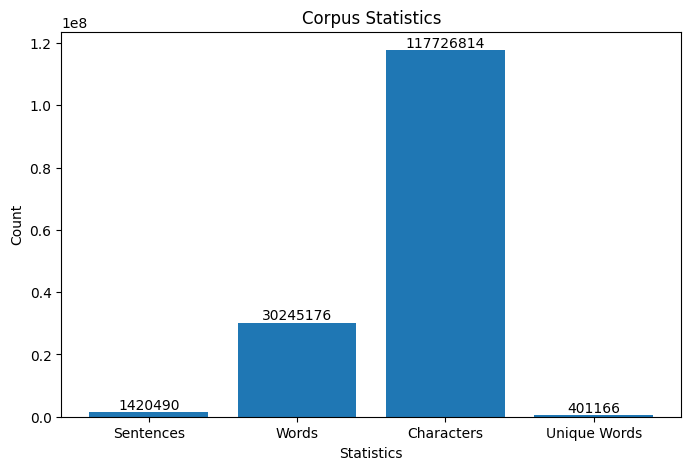

In [47]:
import matplotlib.pyplot as plt

labels = [
    "Sentences",
    "Words",
    "Characters",
    "Unique Words"
]

values = [
    total_sentences,
    total_words,
    total_characters,
    unique_words
]

plt.figure(figsize=(8,5))
plt.bar(labels, values)

plt.title("Corpus Statistics")
plt.xlabel("Statistics")
plt.ylabel("Count")

for i, v in enumerate(values):
    plt.text(i, v, str(v), ha='center', va='bottom')

plt.show()

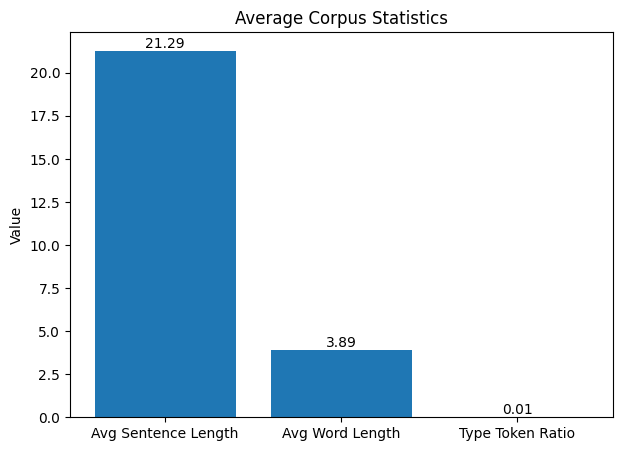

In [48]:
labels = [
    "Avg Sentence Length",
    "Avg Word Length",
    "Type Token Ratio"
]

values = [
    average_sentence_length,
    average_word_length,
    type_token_ratio
]

plt.figure(figsize=(7,5))
plt.bar(labels, values)

plt.title("Average Corpus Statistics")
plt.ylabel("Value")

for i, v in enumerate(values):
    plt.text(i, v, f"{v:.2f}", ha='center', va='bottom')

plt.show()

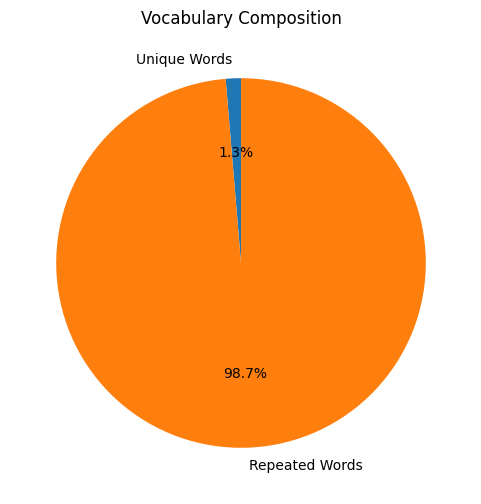

In [49]:
labels = [
    "Unique Words",
    "Repeated Words"
]

values = [
    unique_words,
    total_words - unique_words
]

plt.figure(figsize=(6,6))
plt.pie(
    values,
    labels=labels,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Vocabulary Composition")
plt.show()